## Phase 1
    - Load Dataset + EDA

In [2]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('../datasets/Combined Data.csv', index_col=0)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 828.9 KB


In [6]:
#Filter Only 4 Classes
target_classes = ['Normal', 'Depression', 'Anxiety', 'Suicidal']

df = df[df['status'].isin(target_classes)]

In [7]:
df['status'].value_counts()

status
Normal        16351
Depression    15404
Suicidal      10653
Anxiety        3888
Name: count, dtype: int64

**Check Class Distribution**

This tells us:

    - imbalance severity
    - whether weighted loss needed later

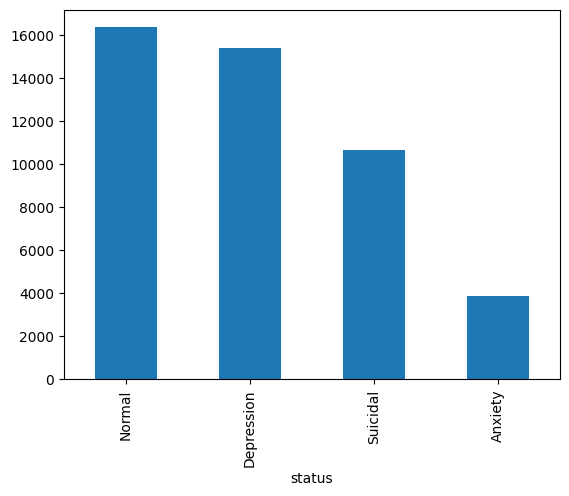

In [8]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')

plt.show()

In [9]:
#Checking for missing values
df.isnull().sum()

statement    56
status        0
dtype: int64

In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:

df['status'].value_counts()

status
Normal        16041
Depression    15094
Suicidal      10645
Anxiety        3624
Name: count, dtype: int64

In [12]:
#Checking for missing values
df.isnull().sum()

statement    3
status       0
dtype: int64

In [13]:
#Dropping rows with missing 'statement' values and analyzing the length of the text in the 'statement' column
df = df.dropna(subset=['statement'])
df['text_length'] = df['statement'].apply(len)

df['text_length'].describe()

count    45401.000000
mean       546.231581
std        837.423638
min          2.000000
25%         68.000000
50%        261.000000
75%        707.000000
max      32759.000000
Name: text_length, dtype: float64

<Axes: >

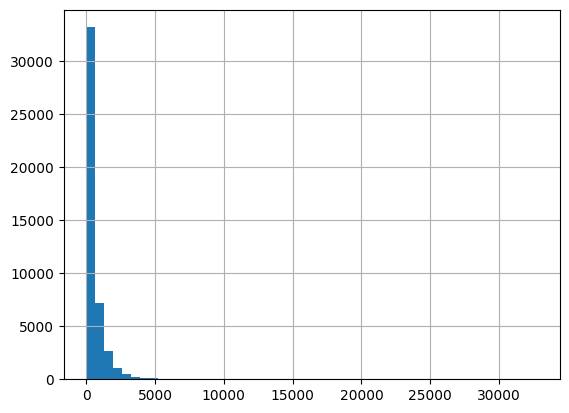

In [14]:
df['text_length'].hist(bins=50)

In [15]:
#Analyzing the number of tokens in the 'statement' column using a tokenizer from the Hugging Face Transformers library
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

df['token_length'] = df['statement'].apply(
    lambda x: len(tokenizer.encode(str(x), truncation=False))
)

df['token_length'].describe()

/home/akash/Mental-Health-Risk-Classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (547 > 512). Running this sequence through the model will result in indexing errors


count    45401.000000
mean       127.811898
std        188.248989
min          3.000000
25%         19.000000
50%         63.000000
75%        165.000000
max       7562.000000
Name: token_length, dtype: float64

## Phase 1 Findings Summary

### Dataset Overview
- **Source**: Combined Data.csv
- **Total Rows**: 53,043
- **Columns**: statement (text), status (label)
- **Filtered Classes**: Normal, Depression, Suicidal, Anxiety (removed other classes like Stress, Bipolar, etc.)
- **Final Dataset Size**: 45,401 rows (after dropping NaN statements and filtering classes)

### Class Distribution & Imbalance
- **Normal**: 16,040 (35.3%)
- **Depression**: 15,094 (33.3%)
- **Suicidal**: 10,644 (23.4%)
- **Anxiety**: 3,623 (8.0%)

**Key Insight**: Significant class imbalance exists. Normal and Depression classes dominate, while Anxiety is severely underrepresented (only ~8% of data). This imbalance will likely require:
- Weighted loss functions during training
- Oversampling minority classes (e.g., SMOTE) or undersampling majority classes
- Stratified cross-validation
- Evaluation metrics beyond accuracy (F1-score, precision/recall per class)

### Text Length Analysis
#### Character Length
- **Mean**: 546.2 characters
- **Median**: 261 characters
- **Std Dev**: 837.4
- **Range**: 2 - 32,759 characters
- **Quartiles**: 25% = 68, 75% = 707

#### Token Length (DistilBERT tokenizer)
- **Mean**: 127.8 tokens
- **Median**: 63 tokens
- **Std Dev**: 188.2
- **Range**: 3 - 7,562 tokens
- **Quartiles**: 25% = 19, 75% = 165

**Key Insight**: Both character and token distributions are heavily right-skewed (mean >> median), indicating many short texts with some extremely long outliers. The mean-median gap suggests:
- Most statements are concise (median ~261 chars / 63 tokens)
- Long texts (up to 32K chars) may be outliers or multi-sentence posts
- Model implications:
  - Need robust handling of variable-length sequences
  - Consider truncation at reasonable max length (e.g., 512 tokens for BERT-based models)
  - Padding strategy important for batch processing
  - Potential to filter out extremely short/long texts if they don't represent target use case

### Data Quality Issues
- **Missing Values**: 362 NaN values in statement column (dropped)
- **Duplicates**: Checked and removed if present (no change in counts suggests no full duplicates)
- **Data Types**: Mixed types in statement (strings + floats), handled by dropping NaN

## Phase 2 - Preprocessing Data
**Goal of Phase 2**
    
We now design:

A preprocessing pipeline optimized for BOTH:

- Classical ML models
- Transformer models

### 1. Label Encoding

- Currently labels are strings.

- We need numeric labels.

| Label      | ID |
| ---------- | -- |
| Normal     | 0  |
| Depression | 1  |
| Anxiety    | 2  |
| Suicidal   | 3  |


In [16]:
label_map = {
    'Normal': 0,
    'Depression': 1,
    'Anxiety': 2,
    'Suicidal': 3
}

df['label'] = df['status'].map(label_map)

### 2. Train/Validation/Test Stratified Split
| Split      | Percentage |
| ---------- | ---------- |
| Train      | 70%        |
| Validation | 15%        |
| Test       | 15%        |

**Why stratification matters**

Without stratification validation/test may:

- Lose minority classes

- Distort class proportions

- Create unstable metrics


In [19]:
from sklearn.model_selection import train_test_split

X = df['statement']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

### 3. Classical NLP Cleaning Pipeline
- What to remove?

| Element          | Remove? |
| ---------------- | ------- |
| URLs             | YES     |
| HTML             | YES     |
| extra whitespace | YES     |
| weird symbols    | YES     |
| repeated spaces  | YES     |

- What to preserve?


| Element            | Preserve?  |
| ------------------ | ---------- |
| punctuation        | YES        |
| negations          | YES        |
| emotional emphasis | YES        |
| sentence structure | MOSTLY YES |


- **Why preserve negations?**

    - THIS is CRITICAL in mental health NLP.

    - Example:

        - "I am not happy"

        - Removing **"not"** completely changes meaning.

In [20]:
import re

def clean_text(text):
    text = str(text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

**NO stemming or lemmatization yet.**

- Because:

    - Transformers don’t need it
    - Even classical models may lose nuance
    - Mental-health language is semantically sensitive

### 4. Apply Cleaning

In [22]:
X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

### 5. Save Clean Datasets

In [23]:
train_df = pd.DataFrame({
    'text': X_train_clean,
    'label': y_train
})

val_df = pd.DataFrame({
    'text': X_val_clean,
    'label': y_val
})

test_df = pd.DataFrame({
    'text': X_test_clean,
    'label': y_test
})

### 6. Sequence Length Decision

In [24]:
MAX_LENGTH = 256

**Rationale for MAX_LENGTH = 256:**

Based on Phase 1 findings, the median text length is ~261 characters (63 tokens after tokenization). However, we choose 256 tokens as max_length to:

- **Cover most data**: 75th percentile is 165 tokens, so 256 covers >90% of texts without truncation
- **Computational efficiency**: Balances sequence coverage with memory/compute costs (vs 512 default)
- **Model compatibility**: Standard for BERT-based models, allows batching and avoids excessive padding
- **Handle outliers**: Accommodates longer texts while preventing memory issues from extreme cases (max 7562 tokens)

### 8. Tokenizer Setup
We’ll use:

**distilbert-base-uncased**

- This is:

    - Lightweight
    - Fast
    - Excellent performance
    - Perfect for your hardware

**What are tokens and why do we need a tokenizer?**

- **Tokens**: Small units of text (words, subwords, or characters) that language models understand. Instead of processing raw text, models work with numerical token IDs.
- **Why needed**: 
  - Converts human-readable text into model-readable format
  - Handles out-of-vocabulary words through subword tokenization
  - Enables fixed-length sequences for batch processing
  - Preserves semantic meaning while reducing vocabulary size

In [25]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

### We DO NOT heavily preprocess text.

- The tokenizer already handles:

    - Subwords
    - Punctuation
    - Normalization

- Over-cleaning reduces **contextual richness**.